In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from sklearn.metrics import roc_curve, auc

fig_dir = './figs/'

df_all = pd.read_csv('paper-figure_celllist_all.csv')

facilities = {
    '1_CIH': 'C',
    '2_Tsukuba': 'T',
    '3_Kaetsu': 'K',
    '4_Junten': 'J' 
}

custom_stack_order = ['Squ.epi', 'Squ.meta', 'Navicular', 'Para.Squ', 'Para.Clust', 'Glan', 'Leu','Debris', 'LSIL', 'HSIL', 'Adenocarcinoma']

probability_threshold = 0.8
for param in custom_stack_order:
    df_all[param] = df_all[f'class_count-{probability_threshold}'].apply(ast.literal_eval).apply(lambda x: x.get(param, 0))


LSIL+ samples: 427 / 785


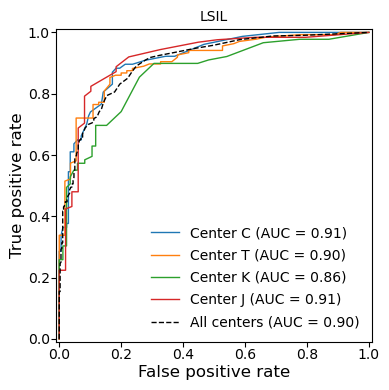

HSIL+ samples: 185 / 1097


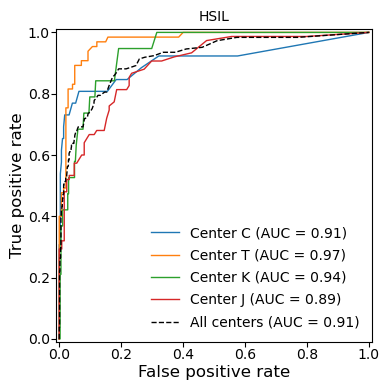

In [2]:
df_temp = df_all.query('Class != "ASC-US"').copy()
df_temp['label_lsil'] = df_temp['Class'].isin(['LSIL', 'ASC-H', 'HSIL', 'SCC']).astype(int)
df_temp['score_lsil'] = df_temp['LSIL'] + df_temp['HSIL']
print(f'LSIL+ samples: {df_temp["label_lsil"].sum()} / {df_temp.shape[0]}')

plt.figure(figsize=(4, 4))
for facility in facilities.keys():
    df_facility = df_temp.query('Facility == @facility')
    fpr_lsil, tpr_lsil, _ = roc_curve(df_facility['label_lsil'], df_facility['score_lsil'])
    auc_lsil = auc(fpr_lsil, tpr_lsil)
    plt.plot(fpr_lsil, tpr_lsil, lw=1, label=f'Center {facilities[facility]} (AUC = {auc_lsil:.2f})')

fpr_lsil, tpr_lsil, _ = roc_curve(df_temp['label_lsil'], df_temp['score_lsil'])
auc_lsil = auc(fpr_lsil, tpr_lsil)
plt.plot(fpr_lsil, tpr_lsil, color='black', linestyle='--', lw=1, label=f'All centers (AUC = {auc_lsil:.2f})')
plt.xlabel("False positive rate", fontsize=12, labelpad=2)
plt.ylabel("True positive rate", fontsize=12, labelpad=2)
plt.title('LSIL', fontsize=10)
plt.tick_params(axis='both', labelsize=10, pad=1)
plt.margins(x=0.01, y=0.01)
plt.legend(loc="lower right", fontsize=10, frameon=False, labelspacing=0.6)
plt.grid(False)
plt.tight_layout()
plt.savefig(fig_dir + 'roc_lsil.svg', dpi=300)
plt.show()


df_temp = df_all.query('Class != "ASC-H"').copy()
df_temp['label_hsil'] = df_temp['Class'].isin(['HSIL', 'SCC']).astype(int)
df_temp['score_hsil'] = df_temp['HSIL']
print(f'HSIL+ samples: {df_temp["label_hsil"].sum()} / {df_temp.shape[0]}')

plt.figure(figsize=(4, 4))
for facility in facilities.keys():
    df_facility = df_temp.query('Facility == @facility')
    fpr_hsil, tpr_hsil, _ = roc_curve(df_facility['label_hsil'], df_facility['score_hsil'])
    auc_hsil = auc(fpr_hsil, tpr_hsil)
    plt.plot(fpr_hsil, tpr_hsil, lw=1, label=f'Center {facilities[facility]} (AUC = {auc_hsil:.2f})')

fpr_hsil, tpr_hsil, _ = roc_curve(df_temp['label_hsil'], df_temp['score_hsil'])
auc_hsil = auc(fpr_hsil, tpr_hsil)
plt.plot(fpr_hsil, tpr_hsil, color='black', linestyle='--', lw=1, label=f'All centers (AUC = {auc_hsil:.2f})')
plt.xlabel("False positive rate", fontsize=12, labelpad=2)
plt.ylabel("True positive rate", fontsize=12, labelpad=2)
plt.title('HSIL', fontsize=10)
plt.tick_params(axis='both', labelsize=10, pad=1)
plt.margins(x=0.01, y=0.01)
plt.legend(loc="lower right", fontsize=10, frameon=False, labelspacing=0.6)
plt.grid(False)
plt.tight_layout()
plt.savefig(fig_dir + 'roc_hsil.svg', dpi=300)
plt.show()
